In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Tuple, List, Dict, Any


from sklearn.linear_model import LogisticRegression
from scipy.special import logit

import warnings
warnings.filterwarnings("ignore")



## Model 
$$ X \sim \mathcal{N}_d(\mu Y , \Sigma), \quad \Sigma = \sigma^2 I_d + V \Lambda V^\top $$
$$ X \stackrel{d}{=} \mu Y + \sigma Z + W \Lambda^{1/2} V^\top , \quad Z \sim \mathcal{N}(0, I_d), \ W \sim \mathcal{N}(0, I_s) $$

In [324]:
@dataclass
class SpikedIsotropic:
    d: int
    s: int
    spikes_val: list
    spikes_vect: np.ndarray
    mu: np.ndarray 
    sigma: float
    seed: int
    rng: np.random.Generator  = field(init=False) 
    V: np.ndarray = field(init=False)
    Lambda_sqrt: np.ndarray = field(init=False)

    def __post_init__(self):
        if self.s > self.d:
            raise ValueError(f"Cannot have more spikes ({self.s}) than dimensions ({self.d}).")

        self.V = np.column_stack(self.spikes_vect)
        if not np.allclose(self.V.T @ self.V, np.eye(self.s)):
            raise ValueError("Spikes vectors must be orthonormal.")
        
        self.rng = np.random.default_rng(self.seed)

        self.Lambda_sqrt = np.diag(np.sqrt(self.spikes_val))
    
    def _sample_class(self, n_samples: int, sign: int) -> np.ndarray:
        Z = self.rng.standard_normal((n_samples, self.d))
        W = self.rng.standard_normal((n_samples, self.s))
        
        # Construct signal
        signal = sign * self.mu
        
        # Construct noise
        isotropic_noise = self.sigma * Z
        spiked_noise = W @ self.Lambda_sqrt @ self.V.T
        
        return signal + isotropic_noise + spiked_noise
 
    def sample(self, N: int, M: int, N_test: int) -> Tuple[np.ndarray, ...]:

        p = 0.5

        n_pos_lab = self.rng.binomial(N, p)
        n_neg_lab = N - n_pos_lab
        m_pos_unl = self.rng.binomial(M, p)
        m_neg_unl = M - m_pos_unl
        n_pos_test = self.rng.binomial(N_test, p)
        n_neg_test = N_test - n_pos_test

        X_pos_lab = self._sample_class(n_pos_lab, sign=1)
        X_neg_lab = self._sample_class(n_neg_lab, sign=-1)
        X_lab = np.vstack([X_pos_lab, X_neg_lab])
        Y_lab = np.concatenate([np.ones(n_pos_lab), -np.ones(n_neg_lab)])

        X_pos_unl = self._sample_class(m_pos_unl, sign=1)
        X_neg_unl = self._sample_class(m_neg_unl, sign=-1)
        X_unl = np.vstack([X_pos_unl, X_neg_unl])

        X_pos_test = self._sample_class(n_pos_test, sign=1)
        X_neg_test = self._sample_class(n_neg_test, sign=-1)
        X_test = np.vstack([X_pos_test, X_neg_test])
        Y_test = np.concatenate([np.ones(n_pos_test), -np.ones(n_neg_test)])

        shuffled_idx_lab = self.rng.permutation(N)
        shuffled_idx_unl = self.rng.permutation(M)
        shuffled_idx_test = self.rng.permutation(N_test)

        return (
            X_lab[shuffled_idx_lab], 
            Y_lab[shuffled_idx_lab], 
            X_unl[shuffled_idx_unl], 
            X_test[shuffled_idx_test], 
            Y_test[shuffled_idx_test]
        )

## Algorithm

$$\min_{\theta \in \mathbb{R}^{d+1}} \sum_{i=1}^N \frac{1}{N} \ell(Y_i u_{\theta}(X_i)) + \sum_{j \in I_t} \frac{\gamma}{|I_t|} \ell(Y_j u_{\theta}(X_j)) + \frac{\lambda}{2} \|w\|_2^2, \quad \theta = (b, w)$$

$$\min_{\theta \in \mathbb{R}^{d+1}} \frac{1}{\lambda} \left( \sum_{i=1}^N \frac{1}{N} \ell_i + \sum_{j \in I_t} \frac{\gamma}{|I_t|} \ell_j \right) + \frac{1}{2} \|w\|_2^2, \quad \ell_k = \ell(Y_k u_{\theta}(X_k))$$

$$\min_{\theta \in \mathbb{R}^{d+1}} C \left( \sum_{i=1}^N s_i \ell_i + \sum_{j \in I_t} s_j \ell_j \right) + \frac{1}{2} \|w\|_2^2, \quad C = \frac{1}{\lambda}, \ s_i = \frac{1}{N}, \ s_j = \frac{\gamma}{|I_t|} $$

In [3]:
@dataclass
class SelfTrainingExperiment:
    X_lab: np.ndarray
    Y_lab: np.ndarray
    X_unl: np.ndarray
    X_test: np.ndarray
    Y_test: np.ndarray

    def _fit_logistic(self, X_pseudo: np.ndarray, Y_pseudo: np.ndarray, 
                      gamma: float, lambd: float) -> LogisticRegression:

        N_lab = self.X_lab.shape[0]
        N_pseudo = X_pseudo.shape[0]

        if N_pseudo == 0:
            X_combined = self.X_lab
            Y_combined = self.Y_lab
            sample_weights = np.full(N_lab, 1.0 / N_lab)
        else:
            X_combined = np.vstack([self.X_lab, X_pseudo])
            Y_combined = np.concatenate([self.Y_lab, Y_pseudo])
            
            weights_lab = np.full(N_lab, 1.0 / N_lab)
            weights_pseudo = np.full(N_pseudo, gamma / N_pseudo)
            sample_weights = np.concatenate([weights_lab, weights_pseudo])
        
        C_param = 1.0 / lambd if lambd > 0 else 1e9

        clf = LogisticRegression(
            penalty='l2',
            C=C_param,
            fit_intercept=True, 
            solver='lbfgs',
            max_iter=1000,
            tol=1e-6
        )

        clf.fit(X_combined, Y_combined, sample_weight=sample_weights)

        return clf

    def run(self, kappa: float, gamma: float, lambd: float, T: int) -> List[float]:
        empty_X = np.empty((0, self.X_lab.shape[1]))
        empty_Y = np.empty(0)
        
        clf = self._fit_logistic(empty_X, empty_Y, gamma, lambd)
        errors = [1.0 - clf.score(self.X_test, self.Y_test)]

        for t in range(T):
            scores = clf.decision_function(self.X_unl)
            
            mask = np.abs(scores) >= kappa

            if mask.sum() == 0:
                errors.append(errors[-1])
                continue

            Y_pseudo = np.where(scores[mask] >= 0, 1, -1)
            X_pseudo = self.X_unl[mask]

            clf = self._fit_logistic(X_pseudo, Y_pseudo, gamma, lambd)

            errors.append(1.0 - clf.score(self.X_test, self.Y_test))

        return errors

In [326]:
def run_parameter_sweep(data_gen: 'SpikedIsotropic', 
                        N: int, M: int, N_test: int, 
                        base_params: Dict[str, float], 
                        sweep_param_name: str, 
                        sweep_param_values: List[float], 
                        seeds: List[int], 
                        T: int) -> np.ndarray:

    length = len(sweep_param_values)
    runs = len(seeds)
    res = np.zeros((length, runs, T + 1))

    for j, current_seed in enumerate(seeds):
        
        # 1. Forcefully reset the Data Generator's RNG state.
        # This mathematically guarantees that Run 'j' ALWAYS utilizes the exact 
        # same dataset, across all subplots, and across all independent executions.
        data_gen.rng = np.random.default_rng(current_seed)
        
        # 2. Generate the paired dataset
        X_lab, Y_lab, X_unl, X_test, Y_test = data_gen.sample(N, M, N_test)
        
        # 3. Instantiate the isolated environment
        experiment = SelfTrainingExperiment(X_lab, Y_lab, X_unl, X_test, Y_test)

        # 4. Evaluate all parameter variations on this exact environment
        for i, val in enumerate(sweep_param_values):
            
            current_params = base_params.copy()
            current_params[sweep_param_name] = val
            
            errors = experiment.run(
                kappa=current_params['kappa'],
                gamma=current_params['gamma'],
                lambd=current_params['lambd'],
                T=T
            )
            res[i, j, :] = errors

    return res

In [327]:
def plot_parameter_sweep(
    res: np.ndarray, 
    sweep_param_name: str, 
    sweep_param_values: List[float], 
    base_params: Dict[str, float], 
    N: int, M: int, T: int
):
    """
    Plots the test error trajectories across the varied parameter.
    """
    length = len(sweep_param_values)
    cmap = plt.colormaps['plasma'] 
    
    fig, axes = plt.subplots(1, length, figsize=(5 * length, 5), sharey=True)
    
    # Handle the edge case where length=1 (axes is not an array)
    if length == 1:
        axes = [axes]
        
    for i in range(length):
        val = sweep_param_values[i]
        results = res[i]
        
        mean_trajectory = np.mean(results, axis=0)
        median_trajectory = np.median(results, axis=0)
        lower_bound = np.percentile(results, 10, axis=0)
        upper_bound = np.percentile(results, 90, axis=0)

        color_index = i / max(1, length)
        line_color = cmap(color_index)

        # Format the subplot title and legend dynamically
        param_label = f"{sweep_param_name} = {val:.4f}"
        axes[i].set_title(param_label)
        
        axes[i].plot(np.arange(T+1), mean_trajectory, color=line_color, 
                     linewidth=2.0, label="Mean Error")
        axes[i].plot(np.arange(T+1), median_trajectory, color=line_color, 
                     linewidth=1.0, linestyle='--', alpha=0.8, label="Median Error")
                     
        axes[i].fill_between(np.arange(T+1), lower_bound, upper_bound, 
                             color=line_color, alpha=0.2, label="10th-90th Pct")
        
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_xlabel(r"Iterations ($t$)")

    axes[0].set_ylabel(r"Test Error")
    
    # Construct a dynamic super-title showing the fixed parameters
    fixed_str = ", ".join([f"{k}={v:.4f}" for k, v in base_params.items() if k != sweep_param_name])
    fig.suptitle(f"Self-Training Dynamics varying '{sweep_param_name}' | Fixed: {fixed_str} | N={N}, M={M}", fontsize=14)
    
    plt.tight_layout()
    plt.show()

## Isotropic Model Experience

In [365]:
d = 500
s = 1

spikes_val = [0.0 * i + 0.0 for i in range(s)] 

spikes_vect = [np.zeros(d) for _ in range(s)]
for i in range(s):
    spikes_vect[i][i] = 1.0

# Aligned Signal: The signal lives exclusively in the top 5 spiked dimensions.
# Norm is constrained so the problem is not trivially separable.
mu = np.zeros(d)
mu[0:5] = 0.5  # ||mu|| = sqrt(5 * 0.25) = 1.11

sigma = 1.0
seed = 42

data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, seed)

In [ ]:
# Setup Base Parameters
base_params = {
    'kappa': logit(0.75),
    'gamma': 0.5,
    'lambd': 0.01
}

runs = 10
monte_carlo_seeds = list(range(runs))
T = 30
N = 100
M = 10000
N_test = 5000

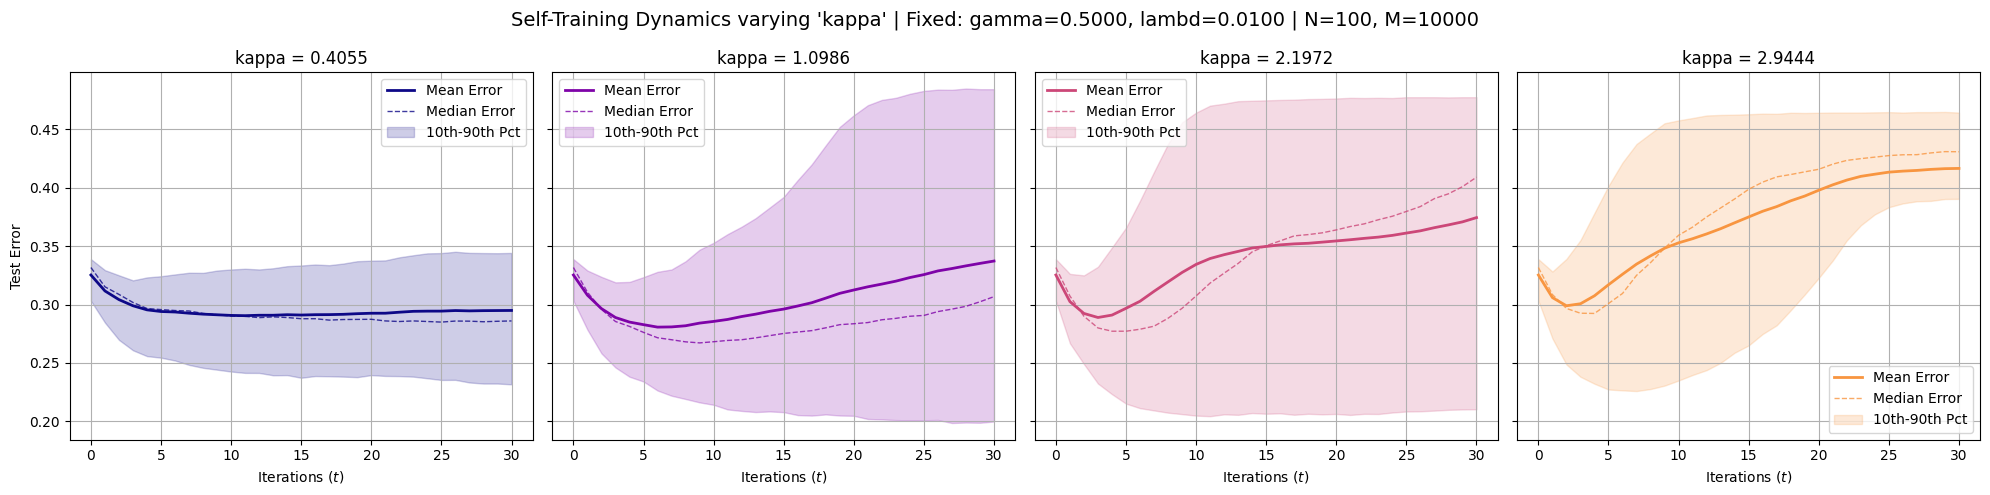

In [367]:
# Define the sweep
target_param = 'kappa'
test_values = [logit(p) for p in [0.6, 0.75, 0.9, 0.95]]

# Run 
res_array = run_parameter_sweep(
    data_gen=data, 
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
    T=T
)

# Plot
plot_parameter_sweep(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, T=T
)

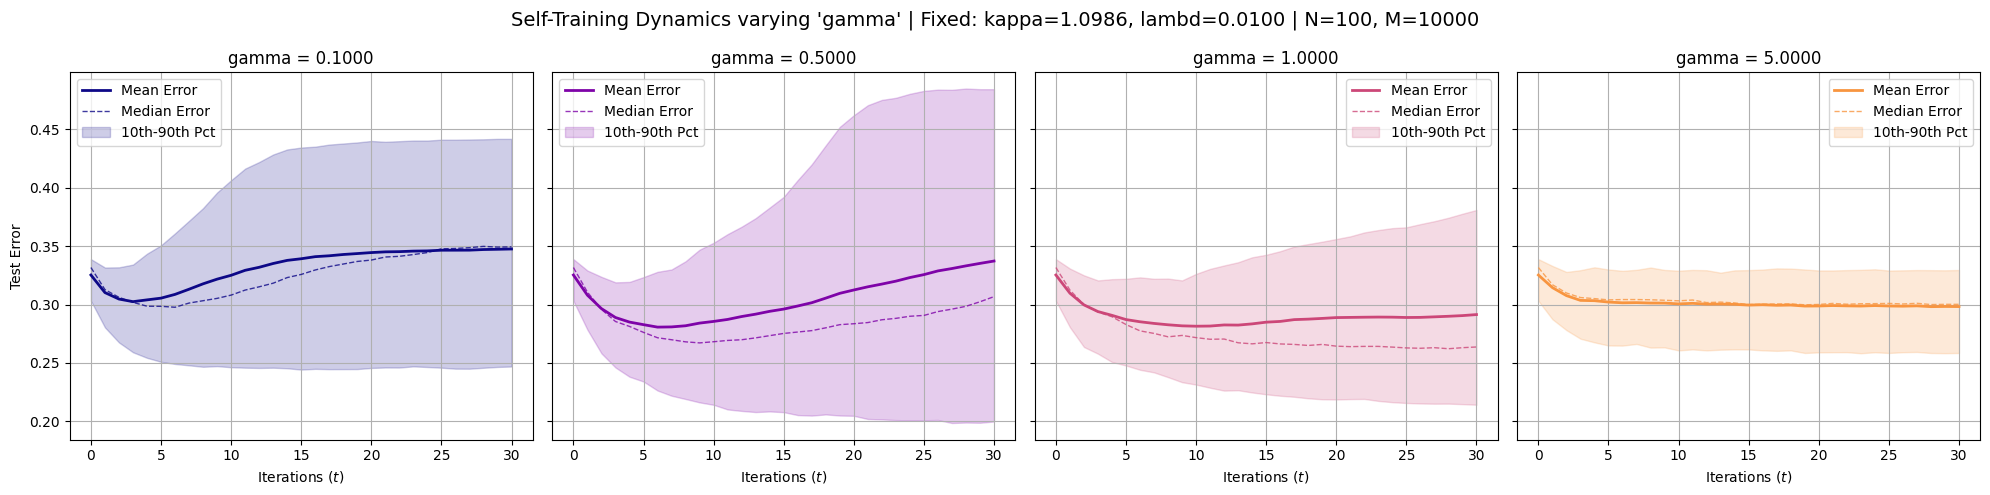

In [368]:
# Define the sweep
target_param = 'gamma'
test_values = [0.1, 0.5, 1.0, 5.0]

# Run 
res_array = run_parameter_sweep(
    data_gen=data, 
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot
plot_parameter_sweep(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, T=T
)

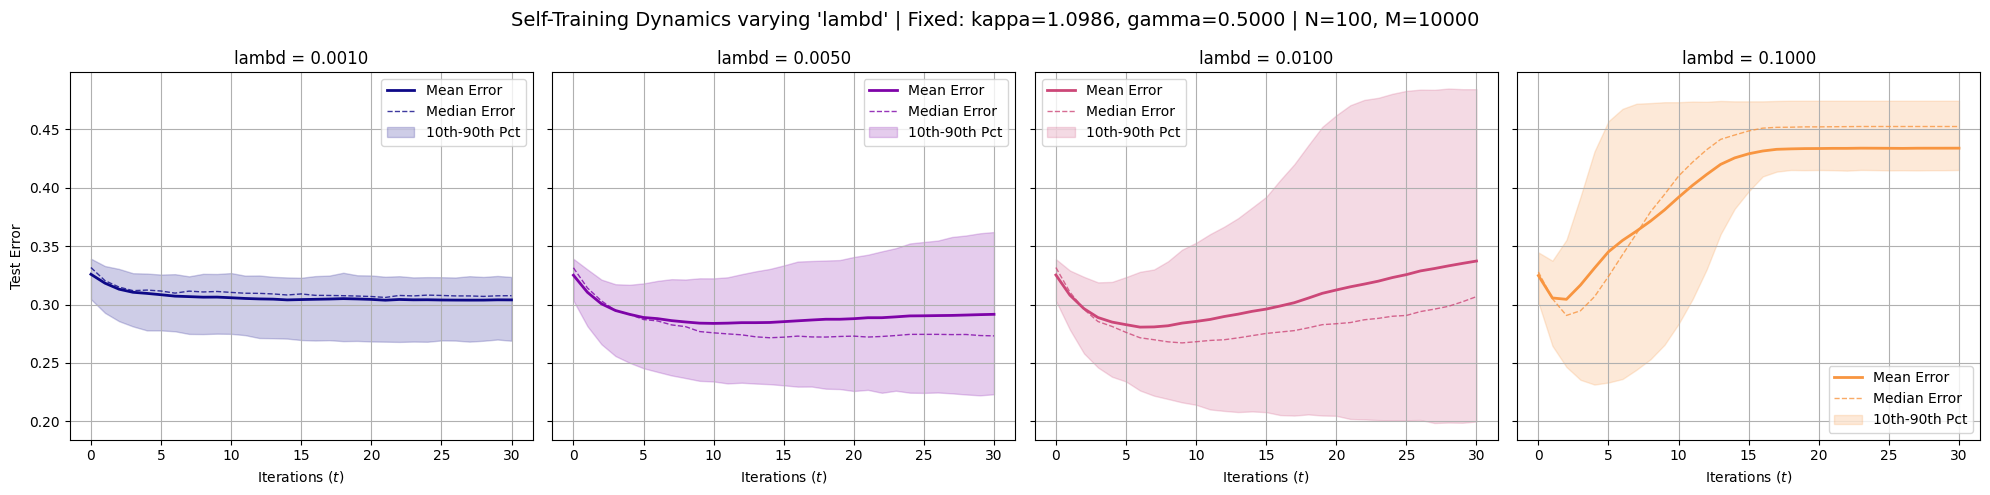

In [369]:
# Define the sweep
target_param = 'lambd'
test_values = [0.001, 0.005, 0.01, 0.1]

# Run 
res_array = run_parameter_sweep(
    data_gen=data, 
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot
plot_parameter_sweep(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, T=T
)

## Spiked Isotropic Model Experience

In [370]:
d = 500
s = 10

spikes_val = [2.0 * i + 2.0 for i in range(s)] 

spikes_vect = [np.zeros(d) for _ in range(s)]
for i in range(s):
    spikes_vect[i][i] = 1.0

# Aligned Signal: The signal lives exclusively in the top 5 spiked dimensions.
# Norm is constrained so the problem is not trivially separable.
mu = np.zeros(d)
mu[0:5] = 0.5  # ||mu|| = sqrt(5 * 0.25) = 1.11

sigma = 1.0
seed = 42

data = SpikedIsotropic(d, s, spikes_val, spikes_vect, mu, sigma, seed)

In [371]:
# Setup Base Parameters
base_params = {
    'kappa': logit(0.75),
    'gamma': 0.5,
    'lambd': 0.01
}

runs = 10
monte_carlo_seeds = list(range(runs))
T = 30
N = 100
M = 10000
N_test = 5000

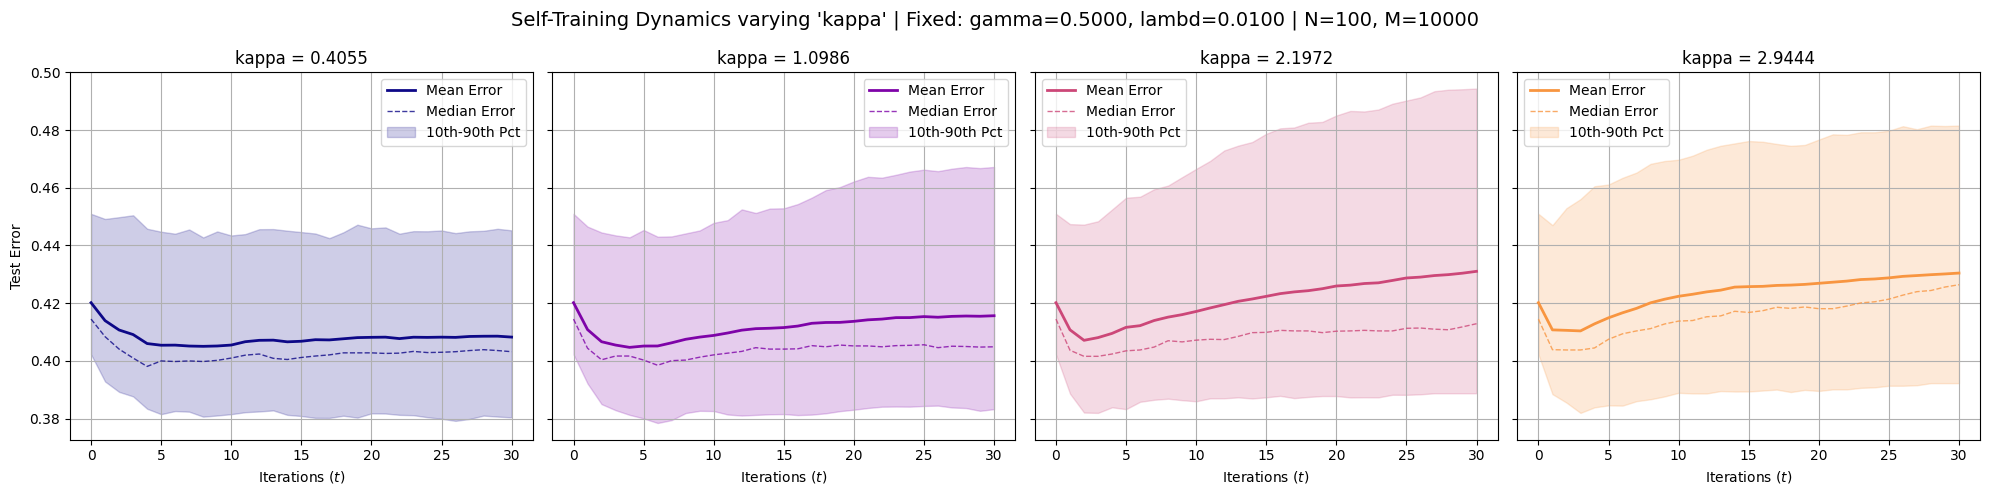

In [372]:
# Define the sweep
target_param = 'kappa'
test_values = [logit(p) for p in [0.6, 0.75, 0.9, 0.95]]

# Run 
res_array = run_parameter_sweep(
    data_gen=data, 
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds,
    T=T
)

# Plot
plot_parameter_sweep(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, T=T
)

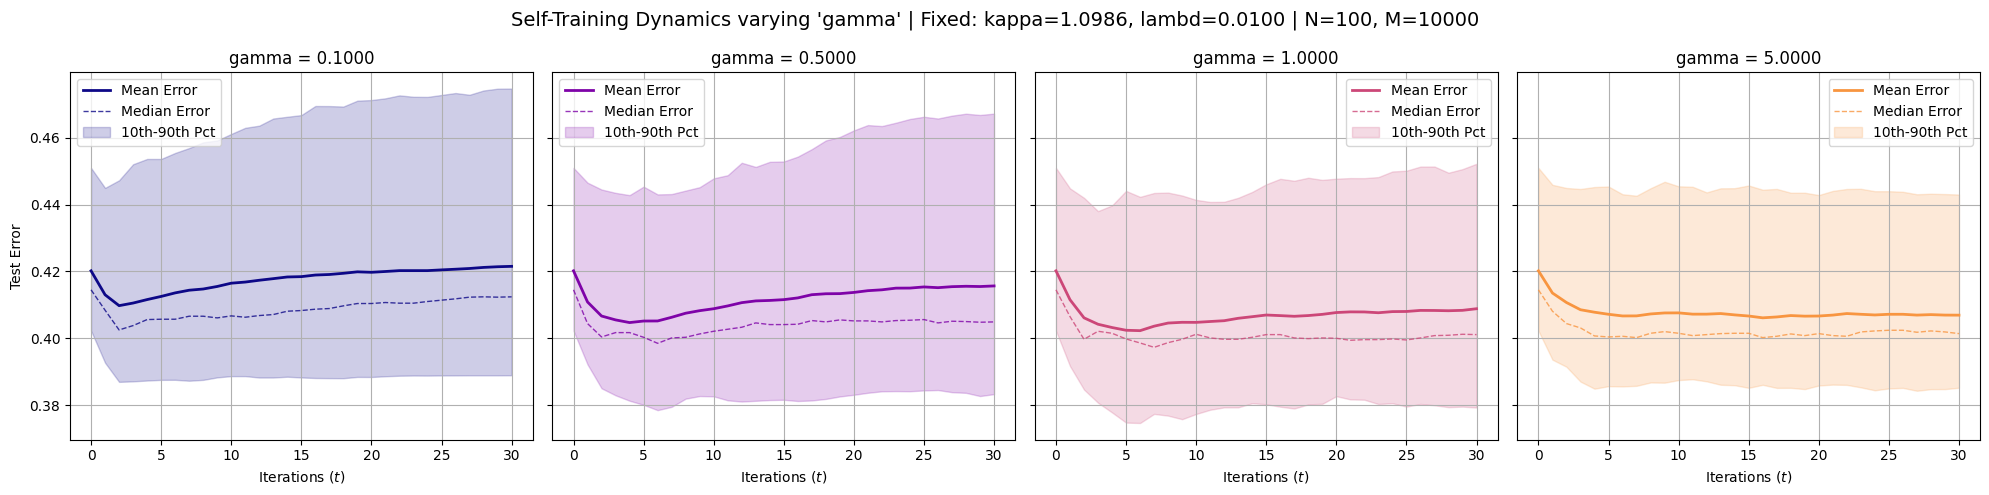

In [373]:
# Define the sweep
target_param = 'gamma'
test_values = [0.1, 0.5, 1.0, 5.0]

# Run 
res_array = run_parameter_sweep(
    data_gen=data, 
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
    T=T
)

# Plot
plot_parameter_sweep(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, T=T
)

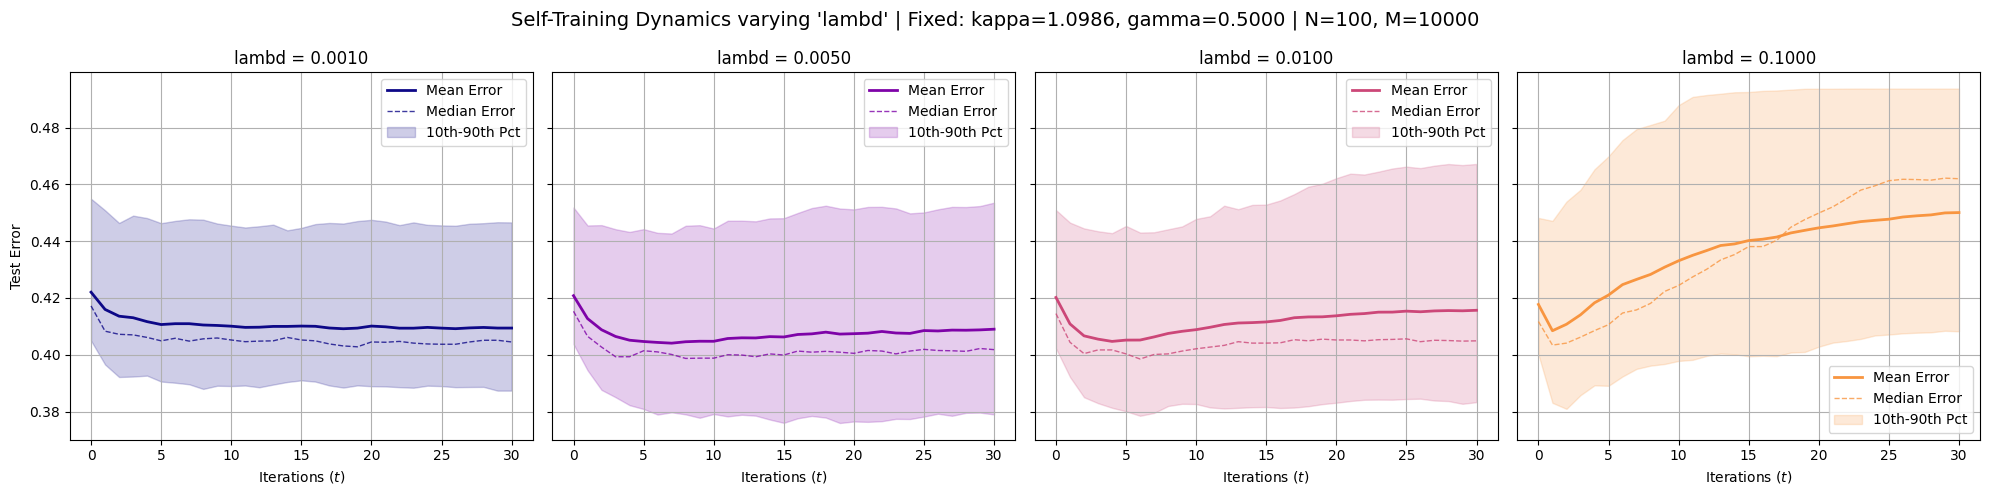

In [374]:
# Define the sweep
target_param = 'lambd'
test_values = [0.001, 0.005, 0.01, 0.1]

# Run 
res_array = run_parameter_sweep(
    data_gen=data, 
    N=N, M=M, N_test=N_test,
    base_params=base_params,
    sweep_param_name=target_param,
    sweep_param_values=test_values,
    seeds=monte_carlo_seeds, 
    T=T
)

# Plot
plot_parameter_sweep(
    res_array, 
    sweep_param_name=target_param, 
    sweep_param_values=test_values, 
    base_params=base_params, 
    N=N, M=M, T=T
)